In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
from pathlib import Path
import pandas as pd

from load import load_comparison
from stats import add_speedup, summary_overall, summary_by_type
from plot import plot_time_scatter, plot_speedup_cdf, plot_median_by_type, plot_speedup_boxplot

## Paths

Apunta a la carpeta con los CSVs de la corrida en godel.
- `bench-xcltj.csv` / `bench-hcltj.csv`: producidos por `bench-query-xcltj` / `bench-query-hcltj`.
- `types.txt`: mapeo `query_id;TYPE{1,2,3}` (en `Queries/`).

In [3]:
RESULTS_DIR = Path("../../results/godel/wikidata-premix-and-fallback-t4000-2026-04-09")
QUERIES_DIR = Path("../../Queries")

xcltj_path = RESULTS_DIR / "bench-xcltj.csv"
hcltj_path = RESULTS_DIR / "bench-hcltj.csv"
types_path = QUERIES_DIR / "types.txt"

## Load

In [4]:
df = load_comparison(xcltj_path, hcltj_path, types_path)
df = add_speedup(df)

print(f"Queries cargadas: {len(df)}")
print(f"Tipos: {df['query_type'].value_counts().to_dict()}")
df.head()

Queries cargadas: 850
Tipos: {'TYPE2': 503, 'TYPE3': 195, 'TYPE1': 152}


,query_id,n_results,time_ns_xcltj,time_us_xcltj,time_ms_xcltj,time_ns_hcltj,time_us_hcltj,time_ms_hcltj,query_type,speedup
0,0,0,32661,32.661,0.032661,39870,39.870,0.039870,TYPE3,0.819187
1,1,0,935615,935.615,0.935615,952596,952.596,0.952596,TYPE3,0.982174
2,2,0,1156027,1156.027,1.156027,1193257,1193.257,1.193257,TYPE3,0.968800
3,3,0,18551,18.551,0.018551,20150,20.150,0.020150,TYPE3,0.920645
4,4,0,250852,250.852,0.250852,259062,259.062,0.259062,TYPE3,0.968309


## Resumen global

In [5]:
summary_overall(df)

,n_queries,median_time_us_xcltj,median_time_us_hcltj,mean_time_us_xcltj,mean_time_us_hcltj,median_speedup,mean_speedup,pct_hcltj_faster
0,850,75.065,75.006,389.297144,382.105618,0.9899,0.996372,35.764706


## Resumen por tipo de query

In [6]:
summary_by_type(df)

,n_queries,median_time_us_xcltj,median_time_us_hcltj,mean_time_us_xcltj,mean_time_us_hcltj,median_speedup,pct_hcltj_faster
query_type,,,,,,,
TYPE1,152,83.3605,84.3805,588.580638,510.163711,0.989916,39.473684
TYPE2,503,81.7500,84.3910,273.457586,263.982716,0.990812,34.990060
TYPE3,195,58.5200,59.0200,532.764867,586.982487,0.984544,34.871795


## Scatter: tiempo X-CLTJ vs H-CLTJ

Puntos **sobre** la diagonal → H-CLTJ es más lento.  
Puntos **bajo** la diagonal → H-CLTJ es más rápido.

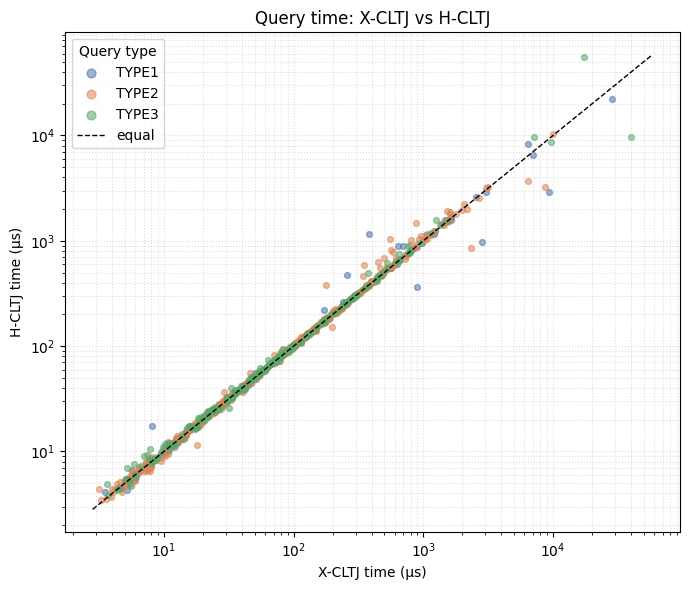

In [7]:
plot_time_scatter(df);

## CDF de speedup por tipo

`speedup = t_xcltj / t_hcltj`.  
Speedup > 1 → H-CLTJ más rápido. Línea roja = igualdad.

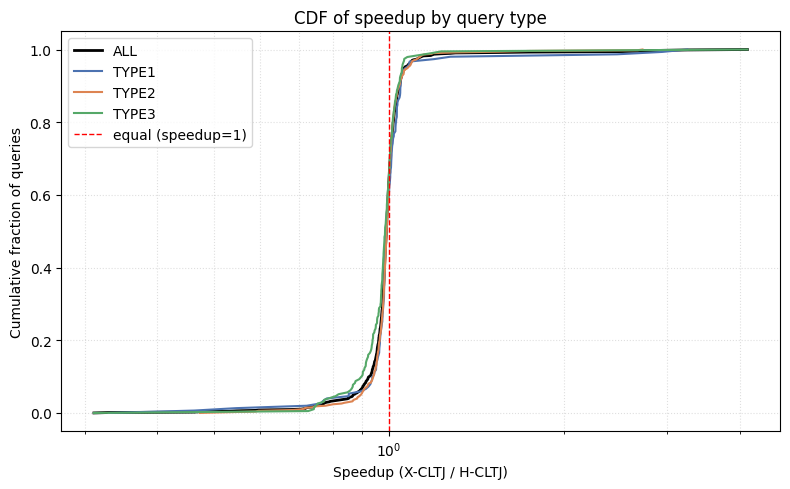

In [8]:
plot_speedup_cdf(df);

## Mediana de tiempos por tipo

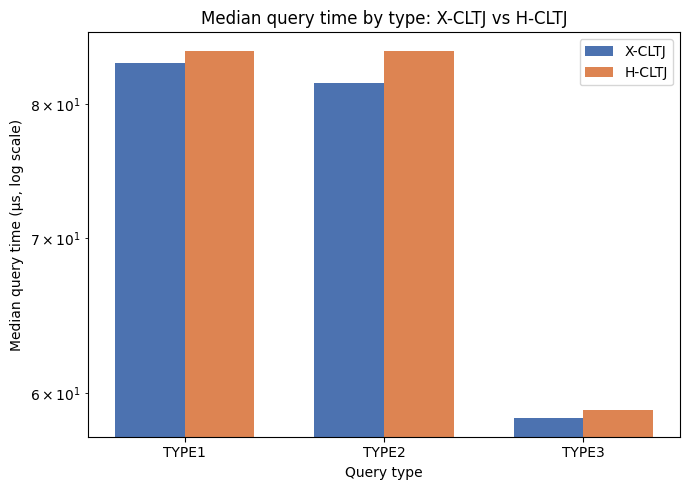

In [9]:
by_type = summary_by_type(df)
plot_median_by_type(by_type);

## Distribución de speedup por tipo (boxplot)

/Users/pabloskewes/FCFM/Magister/cltj/analysis/query_bench/plot.py:144: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


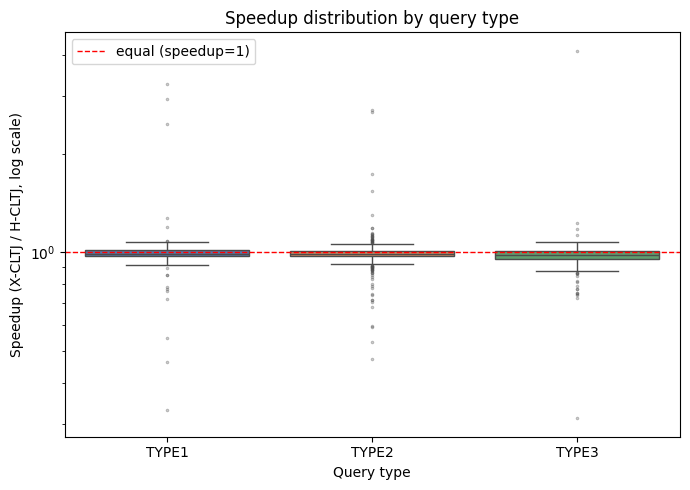

In [10]:
plot_speedup_boxplot(df);